In [23]:
# Imports
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Librería para cargar las imágenes
import glob
# Librería para cargar las coordenadas de las plazas de parking desde XML
import xml.etree.ElementTree as ET

In [24]:
# Funciones

def cargar_coordenadas_plazas_desde_xml(ruta_xml):
    tree = ET.parse(ruta_xml)
    root = tree.getroot()
    coordenadas = []
    for i, obj in enumerate(root.findall('object'), start=1):
        bbox = obj.find('bndbox')
        if bbox is None:
            continue

        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        coordenadas.append((i, xmin, ymin, xmax, ymax))
    return coordenadas

def tratar_recorte_parking(recorte_bgr):
    # Convertimos cualquier recorte de plaza al formato usado por el modelo
    recorte_gray = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2GRAY)
    recorte_128x128 = cv2.resize(recorte_gray, (128, 128))
    recorte_128x128_inv = cv2.bitwise_not(recorte_128x128)
    recorte_aplanado = recorte_128x128_inv.reshape(16384)
    recorte_final = recorte_aplanado.astype(np.float32) / 255.0
    return recorte_final

def tratar_img(ruta_img):
    img = cv2.imread(ruta_img)
    return tratar_recorte_parking(img)

def pintar_plazas_en_frame(frame_bgr, coordenadas, modelo):
    frame_resultado = frame_bgr.copy()
    entradas = []
    coordenadas_frame = []

    for i, xmin, ymin, xmax, ymax in coordenadas:
        x, y, w, h = xmin, ymin, xmax - xmin, ymax - ymin
        parking_recortado = frame_bgr[y:y+h, x:x+w]

        entradas.append(tratar_recorte_parking(parking_recortado))
        coordenadas_frame.append((i, x, y, w, h))

    resultados = []

    predicciones_frame = modelo.predict(np.asarray(entradas, dtype=np.float32))

    for (i, x, y, w, h), prediccion in zip(coordenadas_frame, predicciones_frame):
        if prediccion == 1:
            color = (0, 0, 255)  # Rojo para ocupado
            texto = 'Ocupado'
        else:
            color = (0, 255, 0)  # Verde para libre
            texto = 'Libre'

        cv2.rectangle(frame_resultado, (x, y), (x + w, y + h), color, 2)
        cv2.putText(frame_resultado, texto, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        resultados.append({'plaza': i, 'prediccion': texto})

    return frame_resultado, resultados

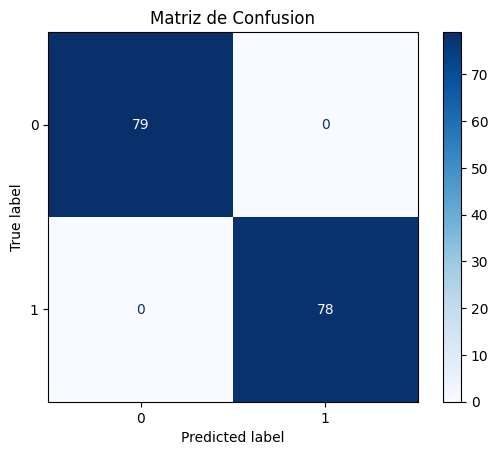

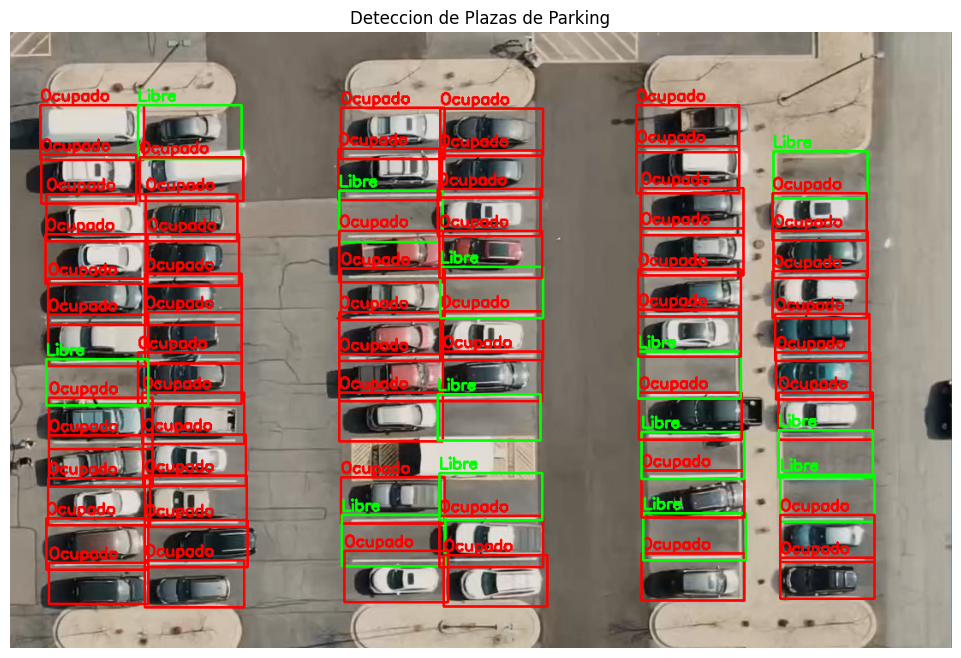

In [25]:
COORDS_PATH = './xml/carpark_coords.xml'
parkings_ocupados = []
parkings_libres = []
etiquetas = []

# Leemos las imágenes y le aseginamos una etiqueta
for img in glob.glob('./images/parking_ocupado/*.png'):
    parkings_ocupados.append(tratar_img(img))
    # Llenamos las etiquetas de 1 (ocupado) por cada foto de parking ocupado
    etiquetas.append(1)

for img in glob.glob('./images/parking_vacio/*.png'):
    parkings_libres.append(tratar_img(img))
    # Llenamos las etiquetas de 0 (libre) por cada foto de parking libre
    etiquetas.append(0)

imagenes_entrenamiento = parkings_ocupados + parkings_libres
# Dividimos el dataset en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    imagenes_entrenamiento,
    etiquetas,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    shuffle=True
 )

# Creamos el modelo KNN
mi_ia = KNeighborsClassifier(n_neighbors=3)

# Entrenamos la IA pasándole los datos de entrenamiento (X_train, y_train)
mi_ia.fit(X_train, y_train)

predicciones = mi_ia.predict(X_test)

# Dibujamos la matriz
matriz = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusion')
plt.show()

# Cargamos una imagen de parking
img_parking = cv2.imread('./images/parkings_ejemplos/carpark_frame.png')

# Cargamos las coordenadas y reutilizamos el pipeline de detección
coordenadas_plazas = cargar_coordenadas_plazas_desde_xml(COORDS_PATH)
img_parking_resultado, _ = pintar_plazas_en_frame(img_parking, coordenadas_plazas, mi_ia)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(img_parking_resultado, cv2.COLOR_BGR2RGB))
plt.title('Deteccion de Plazas de Parking')
plt.axis('off')
plt.show()

In [26]:
import os
from IPython.display import Video, display

RUTA_VIDEO = './videos/carpark.mp4'
RUTA_VIDEO_SALIDA = './videos/carpark_resultado.mp4'


# Preparamos las coordenadas de las plazas a partir del XML
coordenadas_plazas = cargar_coordenadas_plazas_desde_xml(COORDS_PATH)

# Definimos la ruta del video de entrada y del video de salida
os.makedirs('./videos', exist_ok=True)

# Cargamos el video original
cap = cv2.VideoCapture(RUTA_VIDEO)

if not cap.isOpened():
    raise ValueError('No se pudo abrir el video.')

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Creamos el escritor para guardar el video con las detecciones
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(RUTA_VIDEO_SALIDA, fourcc, fps, (ancho, alto))
if not writer.isOpened():
    cap.release()
    raise ValueError('No se pudo crear el video de salida.')

frame_previo = None
resultados = []
frames_procesados = 0

# Recorremos todos los frames del video y aplicamos la detección a cada uno
while True:
    ok, frame = cap.read()
    if not ok:
        break

    frame_resultado, resultados = pintar_plazas_en_frame(frame, coordenadas_plazas, mi_ia)

    if frame_previo is None:
        frame_previo = frame_resultado.copy()

    writer.write(frame_resultado)
    frames_procesados += 1

cap.release()
writer.release()

ocupadas = [r for r in resultados if r['prediccion'] == 'Ocupado']
libres = [r for r in resultados if r['prediccion'] == 'Libre']
ruta_video_generada = os.path.abspath(RUTA_VIDEO_SALIDA)

print(f"Video usado: {os.path.abspath(RUTA_VIDEO)}")
print(f"Frames procesados: {frames_procesados}")
print(f"Video generado: {ruta_video_generada}")
print(f"Plazas libres en el ultimo frame: {len(libres)}")
print(f"Plazas ocupadas en el ultimo frame: {len(ocupadas)}")

Video usado: c:\Users\ASUS\Desktop\Big-Data-e-IA\Programacion de IA\Tratamiento de imagen\Aplicacion mundo real\videos\carpark.mp4
Frames procesados: 679
Video generado: c:\Users\ASUS\Desktop\Big-Data-e-IA\Programacion de IA\Tratamiento de imagen\Aplicacion mundo real\videos\carpark_resultado.mp4
Plazas libres en el ultimo frame: 25
Plazas ocupadas en el ultimo frame: 45
